In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Experiment runs (ResNet18 from scratch; NOT pretrained) ---
runs = [
    # 1000
    dict(
        images=1000,
        model="ResNet18",
        pretrained=False,
        batch_size=32,       
        lr=0.0001,
        max_epochs=20,
        epochs_trained=12,
        best_train_acc=0.9456,
        best_val_acc=0.9933,
        best_val_epoch=7,
        test_acc=0.8667,
        test_loss=0.2187,
        early_stopping=True,
    ),
    # 2000
    dict(
        images=2000,
        model="ResNet18",
        pretrained=False,
        batch_size=64,
        lr=0.00005,
        max_epochs=25,
        epochs_trained=15,
        best_train_acc=0.9385,
        best_val_acc=1.0,
        best_val_epoch=10,
        test_acc=0.9200,
        test_loss=0.1951,
        early_stopping=True,
    ),
    # 3600
    dict(
        images=3600,
        model="ResNet18",
        pretrained=False,
        batch_size=64,
        lr=0.00002,
        max_epochs=30,
        epochs_trained=11,
        best_train_acc=0.9131,
        best_val_acc=1.0,
        best_val_epoch=6,
        test_acc=1.0,
        test_loss=0.0183,
        early_stopping=True,
    ),
    # 5400
    dict(
        images=5400,
        model="ResNet18",
        pretrained=False,
        batch_size=128,
        lr=0.00001,
        max_epochs=30,
        epochs_trained=13,
        best_train_acc=0.8995,
        best_val_acc=1.0,
        best_val_epoch=8,
        test_acc=1.0,
        test_loss=0.0623,
        early_stopping=True,
    ),
    # 9000
    dict(
        images=9000,
        model="ResNet18",
        pretrained=False,
        batch_size=128,          
        lr=0.0000012,
        max_epochs=35,
        epochs_trained=24,
        best_train_acc=0.7346,
        best_val_acc=0.8872,
        best_val_epoch=19,
        test_acc=0.8896,
        test_loss=0.4526,
        early_stopping=True,
    ),
]

In [2]:
df = pd.DataFrame(runs).sort_values("images").reset_index(drop=True)

# Pretty formatting
df["lr_str"] = df["lr"].map(lambda x: f"{x:.8f}".rstrip("0").rstrip("."))
df["generalization_gap"] = (df["best_train_acc"] - df["best_val_acc"]).round(4)
df["val_minus_test"] = (df["best_val_acc"] - df["test_acc"]).round(4)
df["train_minus_test"] = (df["best_train_acc"] - df["test_acc"]).round(4)

# Reorder columns for readability
cols = [
    "images","model","pretrained","batch_size","lr_str","max_epochs","epochs_trained",
    "best_train_acc","best_val_acc","test_acc","test_loss",
    "best_val_epoch","generalization_gap","val_minus_test","train_minus_test",
    "early_stopping"
]
df = df[cols]

df

,images,model,pretrained,batch_size,lr_str,max_epochs,epochs_trained,best_train_acc,best_val_acc,test_acc,test_loss,best_val_epoch,generalization_gap,val_minus_test,train_minus_test,early_stopping
0,1000,ResNet18,False,32,0.0001,20,12,0.9456,0.9933,0.8667,0.2187,7,-0.0477,0.1266,0.0789,True
1,2000,ResNet18,False,64,0.00005,25,15,0.9385,1.0000,0.9200,0.1951,10,-0.0615,0.0800,0.0185,True
2,3600,ResNet18,False,64,0.00002,30,11,0.9131,1.0000,1.0000,0.0183,6,-0.0869,0.0000,-0.0869,True
3,5400,ResNet18,False,128,0.00001,30,13,0.8995,1.0000,1.0000,0.0623,8,-0.1005,0.0000,-0.1005,True
4,9000,ResNet18,False,128,0.0000012,35,24,0.7346,0.8872,0.8896,0.4526,19,-0.1526,-0.0024,-0.1550,True


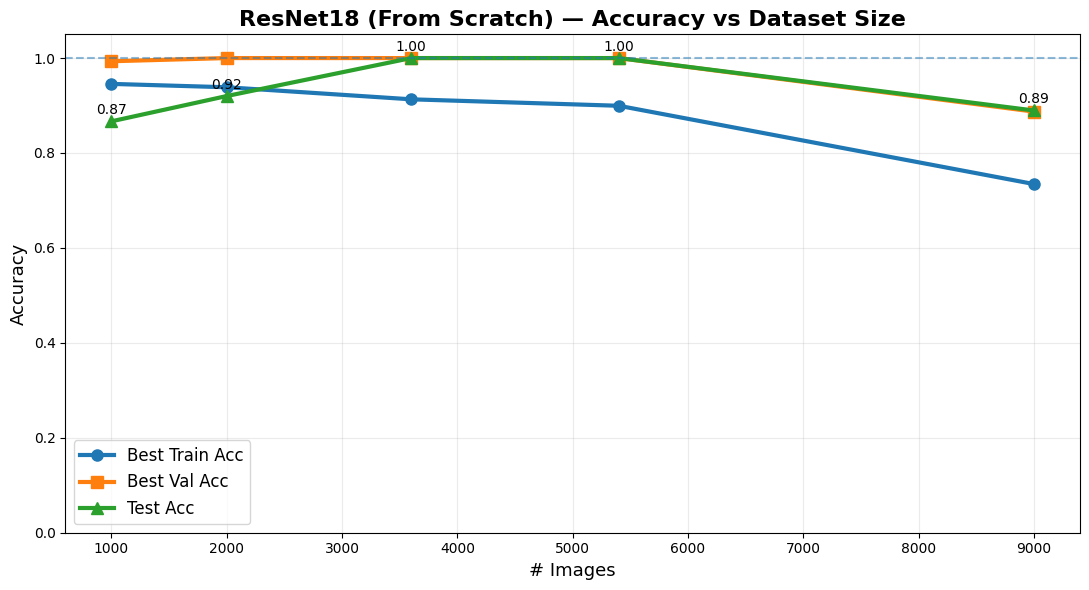

In [3]:
x = df["images"].to_numpy()

plt.figure(figsize=(11,6))
plt.plot(x, df["best_train_acc"], marker="o", linewidth=3, markersize=8, label="Best Train Acc")
plt.plot(x, df["best_val_acc"],   marker="s", linewidth=3, markersize=8, label="Best Val Acc")
plt.plot(x, df["test_acc"],       marker="^", linewidth=3, markersize=8, label="Test Acc")

# reference line
plt.axhline(1.0, linestyle="--", linewidth=1.5, alpha=0.5)

plt.title("ResNet18 (From Scratch) — Accuracy vs Dataset Size", fontsize=16, fontweight="bold")
plt.xlabel("# Images", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)
plt.ylim(0, 1.05)

plt.grid(True, alpha=0.25)
plt.legend(fontsize=12, frameon=True)

# annotate points (test acc)
for xi, yi in zip(x, df["test_acc"]):
    plt.text(xi, yi + 0.015, f"{yi:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

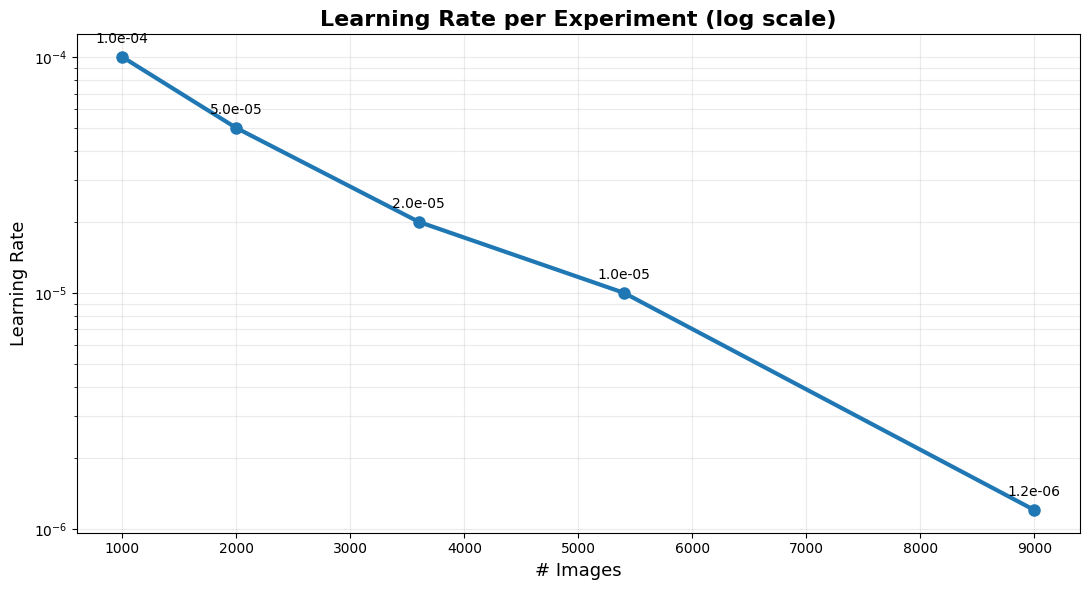

In [4]:
x = df["images"].to_numpy()
lr = df["lr_str"].astype(float).to_numpy()

plt.figure(figsize=(11,6))
plt.plot(x, lr, marker="o", linewidth=3, markersize=8)
plt.yscale("log")

plt.title("Learning Rate per Experiment (log scale)", fontsize=16, fontweight="bold")
plt.xlabel("# Images", fontsize=13)
plt.ylabel("Learning Rate", fontsize=13)

plt.grid(True, alpha=0.25, which="both")

# annotate points with LR
for xi, yi in zip(x, lr):
    plt.text(xi, yi*1.15, f"{yi:.1e}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

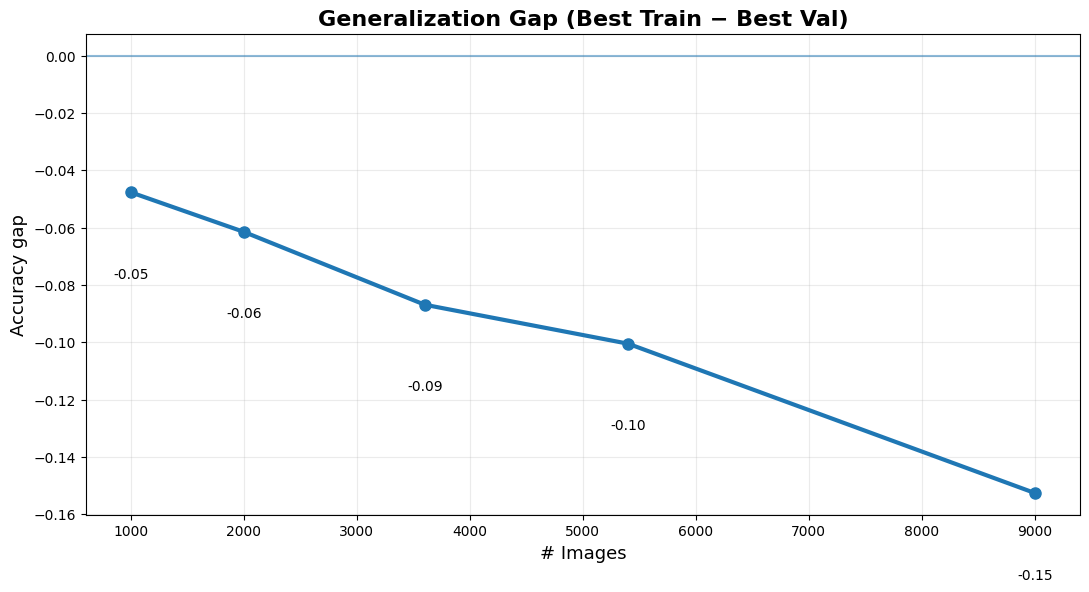

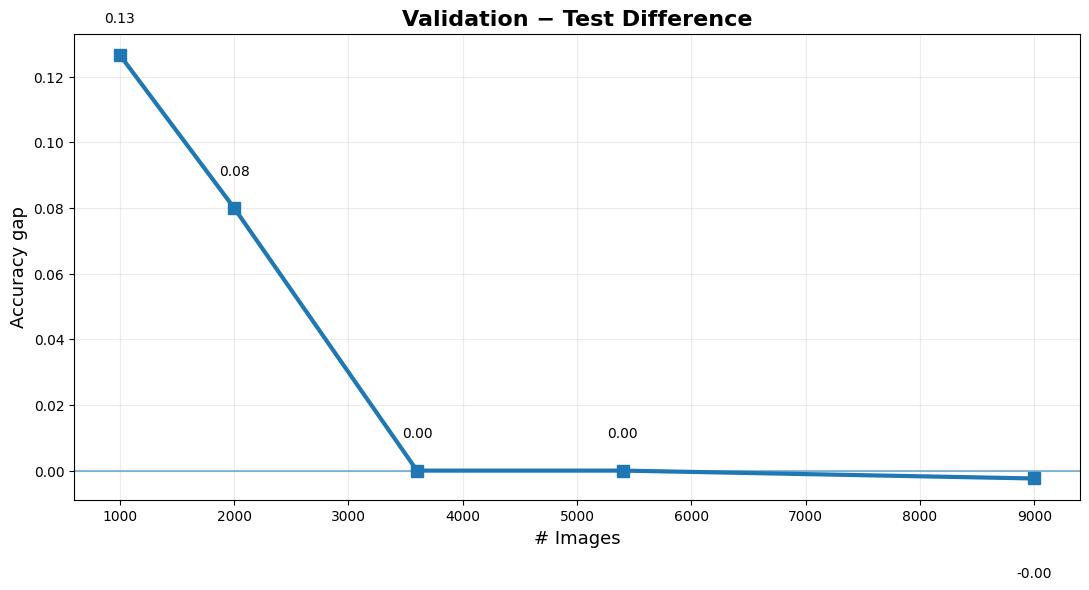

In [5]:
x = df["images"].to_numpy()
gap_tv = df["generalization_gap"].to_numpy()   # train - val
gap_vt = df["val_minus_test"].to_numpy()       # val - test

plt.figure(figsize=(11,6))
plt.plot(x, gap_tv, marker="o", linewidth=3, markersize=8)
plt.axhline(0, linewidth=1.5, alpha=0.5)

plt.title("Generalization Gap (Best Train − Best Val)", fontsize=16, fontweight="bold")
plt.xlabel("# Images", fontsize=13)
plt.ylabel("Accuracy gap", fontsize=13)
plt.grid(True, alpha=0.25)

for xi, yi in zip(x, gap_tv):
    plt.text(xi, yi + (0.01 if yi >= 0 else -0.03), f"{yi:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


plt.figure(figsize=(11,6))
plt.plot(x, gap_vt, marker="s", linewidth=3, markersize=8)
plt.axhline(0, linewidth=1.5, alpha=0.5)

plt.title("Validation − Test Difference", fontsize=16, fontweight="bold")
plt.xlabel("# Images", fontsize=13)
plt.ylabel("Accuracy gap", fontsize=13)
plt.grid(True, alpha=0.25)

for xi, yi in zip(x, gap_vt):
    plt.text(xi, yi + (0.01 if yi >= 0 else -0.03), f"{yi:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

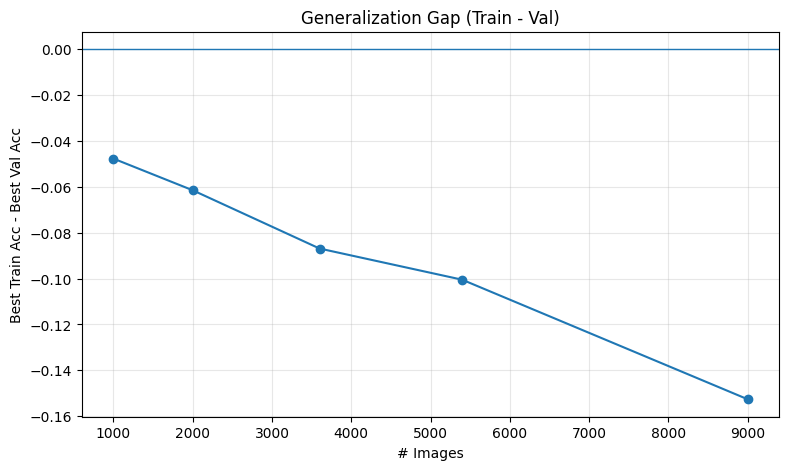

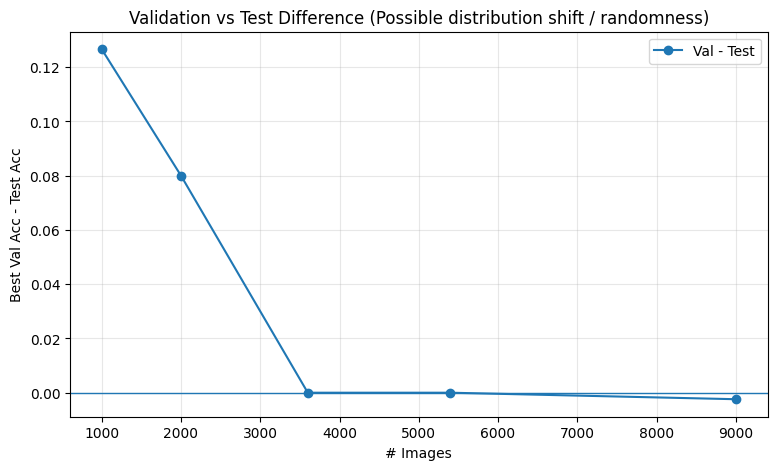

In [6]:
plt.figure(figsize=(9,5))
plt.plot(x, df["generalization_gap"], marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("# Images")
plt.ylabel("Best Train Acc - Best Val Acc")
plt.title("Generalization Gap (Train - Val)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9,5))
plt.plot(x, df["val_minus_test"], marker="o", label="Val - Test")
plt.axhline(0, linewidth=1)
plt.xlabel("# Images")
plt.ylabel("Best Val Acc - Test Acc")
plt.title("Validation vs Test Difference (Possible distribution shift / randomness)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

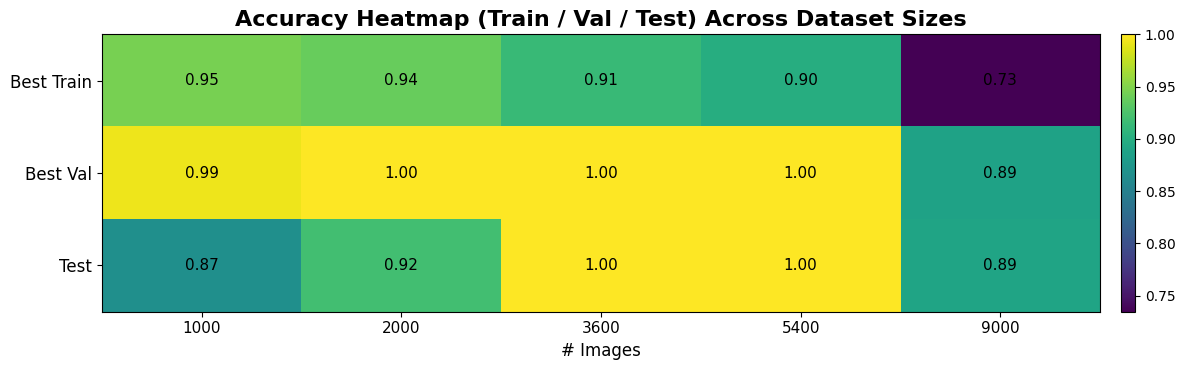

In [7]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["best_train_acc", "best_val_acc", "test_acc"]
M = df[metrics].to_numpy().T  # shape: (3, n)

plt.figure(figsize=(12, 3.8))
im = plt.imshow(M, aspect="auto")

plt.title("Accuracy Heatmap (Train / Val / Test) Across Dataset Sizes", fontsize=16, fontweight="bold")
plt.yticks(range(len(metrics)), ["Best Train", "Best Val", "Test"], fontsize=12)
plt.xticks(range(len(df)), df["images"].astype(str).tolist(), fontsize=11)
plt.xlabel("# Images", fontsize=12)

# numbers inside cells
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        plt.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=11)

plt.colorbar(im, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()

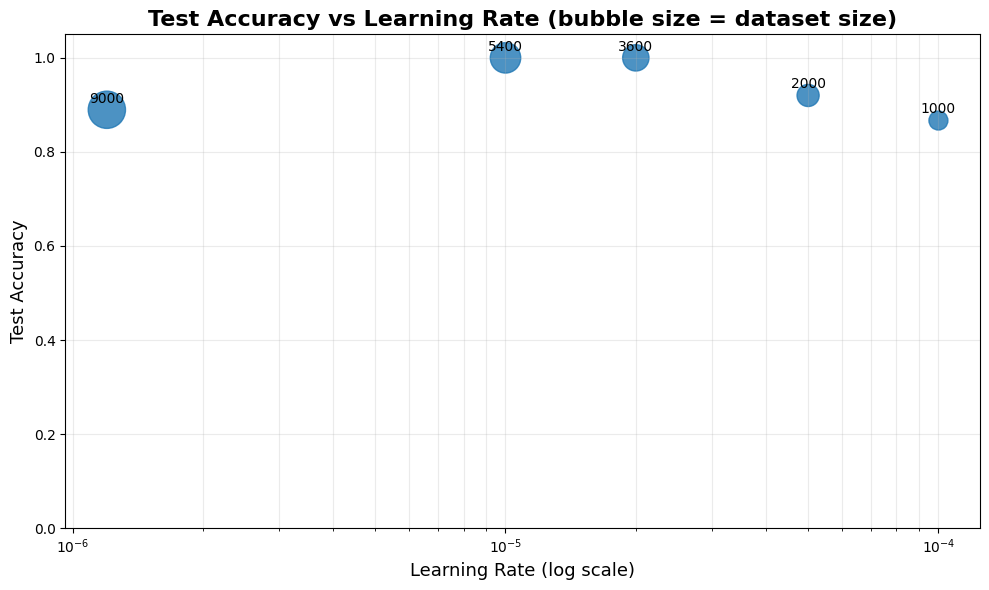

In [8]:
x = df["lr_str"].astype(float).to_numpy()
y = df["test_acc"].to_numpy()
sizes = (df["images"].to_numpy() / df["images"].max()) * 600 + 120  # bubble size

plt.figure(figsize=(10,6))
plt.scatter(x, y, s=sizes, alpha=0.8)
plt.xscale("log")
plt.ylim(0, 1.05)

plt.title("Test Accuracy vs Learning Rate (bubble size = dataset size)", fontsize=16, fontweight="bold")
plt.xlabel("Learning Rate (log scale)", fontsize=13)
plt.ylabel("Test Accuracy", fontsize=13)
plt.grid(True, alpha=0.25, which="both")

for lr, acc, n in zip(x, y, df["images"]):
    plt.text(lr, acc + 0.015, f"{n}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

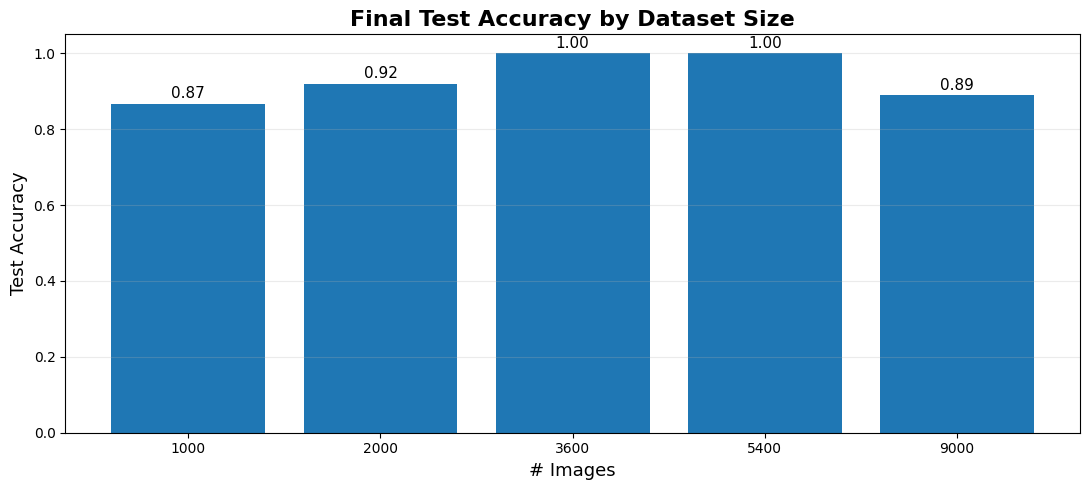

In [9]:
x_labels = df["images"].astype(str).tolist()
y = df["test_acc"].to_numpy()

plt.figure(figsize=(11,5))
bars = plt.bar(x_labels, y)

plt.title("Final Test Accuracy by Dataset Size", fontsize=16, fontweight="bold")
plt.xlabel("# Images", fontsize=13)
plt.ylabel("Test Accuracy", fontsize=13)
plt.ylim(0, 1.05)
plt.grid(True, axis="y", alpha=0.25)

for b, v in zip(bars, y):
    plt.text(b.get_x() + b.get_width()/2, v + 0.015, f"{v:.2f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

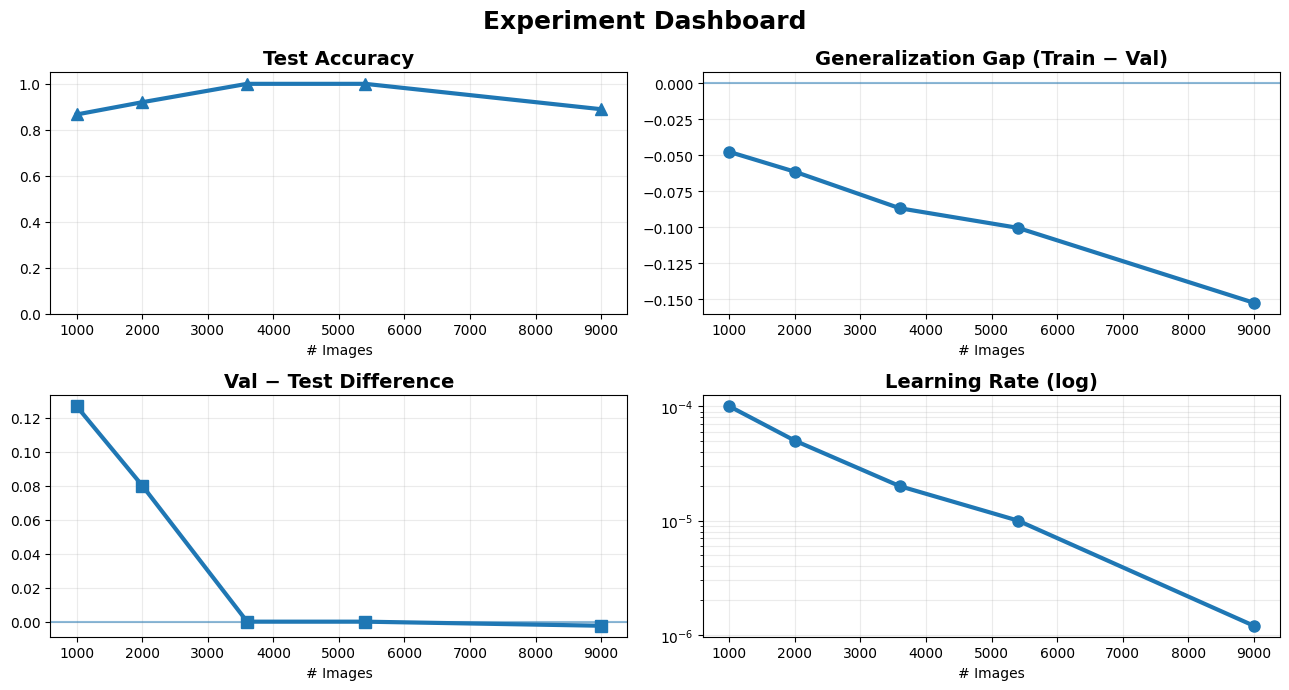

In [10]:
x = df["images"].to_numpy()

fig = plt.figure(figsize=(13,7))

# (1) Test accuracy
ax1 = plt.subplot(2,2,1)
ax1.plot(x, df["test_acc"], marker="^", linewidth=3, markersize=8)
ax1.set_title("Test Accuracy", fontsize=14, fontweight="bold")
ax1.set_xlabel("# Images"); ax1.set_ylim(0, 1.05); ax1.grid(True, alpha=0.25)

# (2) Train - Val gap
ax2 = plt.subplot(2,2,2)
ax2.plot(x, df["generalization_gap"], marker="o", linewidth=3, markersize=8)
ax2.axhline(0, linewidth=1.5, alpha=0.5)
ax2.set_title("Generalization Gap (Train − Val)", fontsize=14, fontweight="bold")
ax2.set_xlabel("# Images"); ax2.grid(True, alpha=0.25)

# (3) Val - Test
ax3 = plt.subplot(2,2,3)
ax3.plot(x, df["val_minus_test"], marker="s", linewidth=3, markersize=8)
ax3.axhline(0, linewidth=1.5, alpha=0.5)
ax3.set_title("Val − Test Difference", fontsize=14, fontweight="bold")
ax3.set_xlabel("# Images"); ax3.grid(True, alpha=0.25)

# (4) LR
ax4 = plt.subplot(2,2,4)
ax4.plot(x, df["lr_str"].astype(float), marker="o", linewidth=3, markersize=8)
ax4.set_yscale("log")
ax4.set_title("Learning Rate (log)", fontsize=14, fontweight="bold")
ax4.set_xlabel("# Images"); ax4.grid(True, alpha=0.25, which="both")

plt.suptitle("Experiment Dashboard", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

In [11]:
from IPython.display import Markdown

# Pull some key points programmatically
best_test = df.loc[df["test_acc"].idxmax()]
worst_test = df.loc[df["test_acc"].idxmin()]
min_lr = df.loc[df["lr_str"].astype(float).idxmin()]
max_lr = df.loc[df["lr_str"].astype(float).idxmax()]

Markdown(f"""
# 📌 Interpretation (ResNet18 from Scratch — Not Pretrained)

## What we can confidently say from the results
- The **best test accuracy** was achieved at **{int(best_test.images)} images** with **test_acc = {best_test.test_acc:.4f}**.
- The **lowest test accuracy** was at **{int(worst_test.images)} images** with **test_acc = {worst_test.test_acc:.4f}**.
- The learning rate range used was very wide:
  - **max LR:** {max_lr.lr_str}
  - **min LR:** {min_lr.lr_str}

## Important scientific note (experimental fairness)
These experiments are **not a “pure” study of dataset size**, because *hyperparameters changed with dataset size* (especially learning rate, and likely batch size / augmentation).
So if accuracy changes when dataset size increases, it may be caused by:
1) dataset size, **or**
2) different learning rate/batch/augmentation, **or**
3) changes in dataset difficulty / sampling / split randomness.

## What the patterns suggest
- For **1000 images**, the gap between **best val (~0.99)** and **test (~0.87)** suggests:
  - potential **validation over-selection** (early stopping based on val),
  - or **test set being harder / distribution shift**,
  - or simply higher variance because the dataset is smaller.

- For **9000 images**, performance is lower (**test ~0.89**) while LR was extremely small (**1.2e-6**),
  which can lead to **under-training/slow convergence** (the model may not fully learn the dataset).

## Conclusion
These results show that **ResNet18 from scratch can reach high accuracy**, but the observed trends cannot be attributed
to dataset size alone unless we run a controlled experiment with:
- same split
- same augmentation
- same optimizer
- and for each dataset size: a small LR search to select the best LR fairly.

✅ This sets up a clean comparison later vs ViT under the *same protocol*.
""")


# 📌 Interpretation (ResNet18 from Scratch — Not Pretrained)

## What we can confidently say from the results
- The **best test accuracy** was achieved at **3600 images** with **test_acc = 1.0000**.
- The **lowest test accuracy** was at **1000 images** with **test_acc = 0.8667**.
- The learning rate range used was very wide:
  - **max LR:** 0.0001
  - **min LR:** 0.0000012

## Important scientific note (experimental fairness)
These experiments are **not a “pure” study of dataset size**, because *hyperparameters changed with dataset size* (especially learning rate, and likely batch size / augmentation).
So if accuracy changes when dataset size increases, it may be caused by:
1) dataset size, **or**
2) different learning rate/batch/augmentation, **or**
3) changes in dataset difficulty / sampling / split randomness.

## What the patterns suggest
- For **1000 images**, the gap between **best val (~0.99)** and **test (~0.87)** suggests:
  - potential **validation over-selection** (early stopping based on val),
  - or **test set being harder / distribution shift**,
  - or simply higher variance because the dataset is smaller.

- For **9000 images**, performance is lower (**test ~0.89**) while LR was extremely small (**1.2e-6**),
  which can lead to **under-training/slow convergence** (the model may not fully learn the dataset).

## Conclusion
These results show that **ResNet18 from scratch can reach high accuracy**, but the observed trends cannot be attributed
to dataset size alone unless we run a controlled experiment with:
- same split
- same augmentation
- same optimizer
- and for each dataset size: a small LR search to select the best LR fairly.

✅ This sets up a clean comparison later vs ViT under the *same protocol*.
